# CUI revision

In [2]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

### Brief revision to CUI

In [5]:
SST = xr.open_dataset('SST.nc').compute()
SST= SST.where(SST.SST!=0,np.nan)
SST

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SST      (time, lat, lon) float32 564MB 20.19 20.18 20.24 ... nan nan nan

In [6]:
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK150km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

from matplotlib.path import Path
LON, LAT = np.meshgrid(SST.lon.values.flatten(),SST.lat.values.flatten())
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

## Offshore 500km 
r5 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK500km.kml"
r6 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK600km.kml"

R5 = kml2struct(r5)
R6 = kml2struct(r6)

# Extract Lon and Lat from the first polygon
lonb5 = R5[0]["Lon"]
latb5 = R5[0]["Lat"]
lonb6 = R6[0]["Lon"]
latb6 = R6[0]["Lat"]

### cutting the 500km
polygon5 = Path(np.column_stack((lonb5, latb5)))
polygon6 = Path(np.column_stack((lonb6, latb6)))

# Check which points are inside the polygon
mask5 = polygon5.contains_points(lonlat_points).reshape(LON.shape)
mask6 = polygon6.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
offshore_mask5 = np.where(mask5, 1, np.nan)
offshore_mask6 = np.where(mask6, 1, np.nan)

space_between_masks = np.where((offshore_mask6 == 1) & (offshore_mask5 != 1), 1, np.nan)

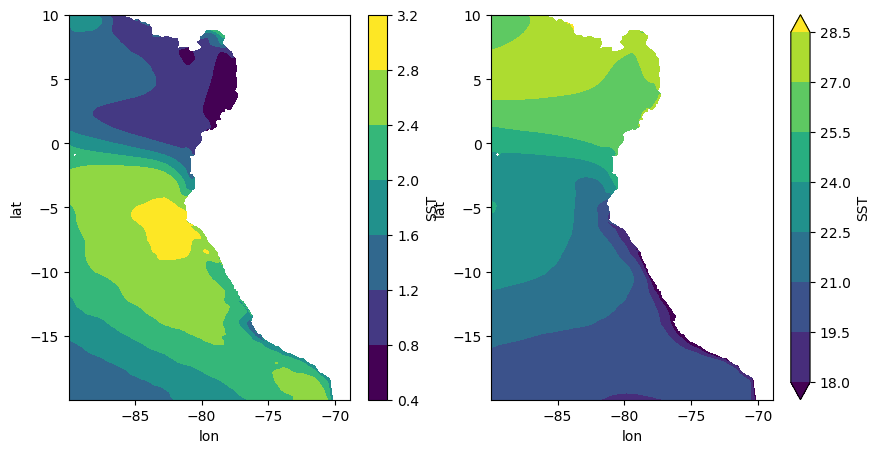

In [7]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
SST.SST.std('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[0])
SST.SST.mean('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[1])

In [8]:
mask = coastal_band_mask(SST,'SST',111).sel(lon=slice(-85,None),lat=slice(-17,-4))
SST_in = SST.where(mask).SST
SST_in

<xarray.DataArray 'SST' (time: 432, lat: 159, lon: 194)> Size: 53MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

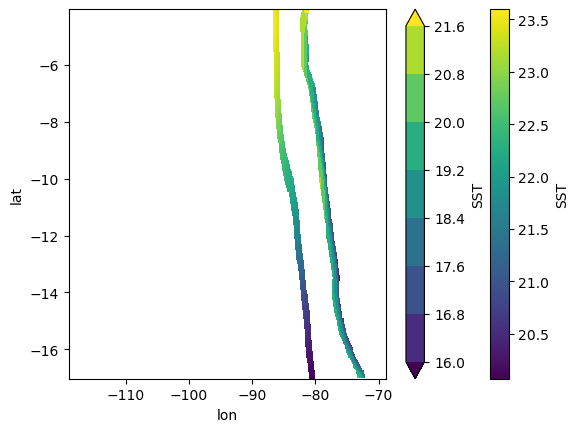

In [9]:
SST_off = (SST*space_between_masks).sel(lat=slice(-17,-4))
SST_off.mean('time').SST.plot()
SST_in.mean('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True)

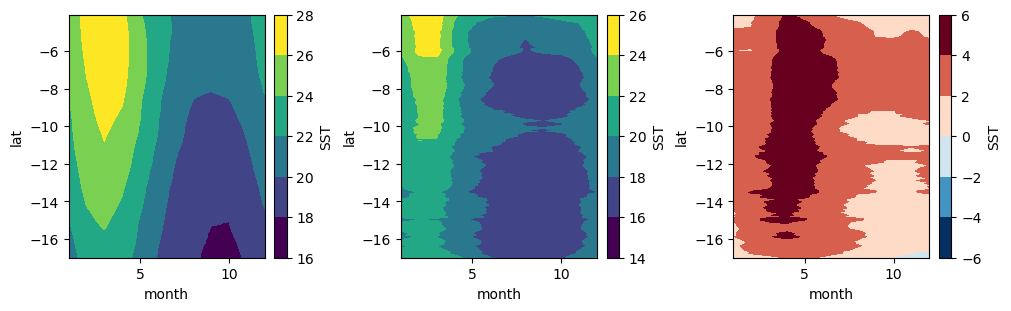

In [10]:
fig,ax = plt.subplots(1,3,figsize=(10,3), constrained_layout=True)
seasonality(SST_off).mean(dim='lon').SST.plot.contourf(x='month',ax=ax[0])
seasonality(SST_in).mean(dim='lon').plot.contourf(x='month',ax=ax[1])
(seasonality(SST_off).mean('lon') - seasonality(SST_in).mean('lon')).SST.plot.contourf(x='month',ax=ax[2])

* Still didn't work

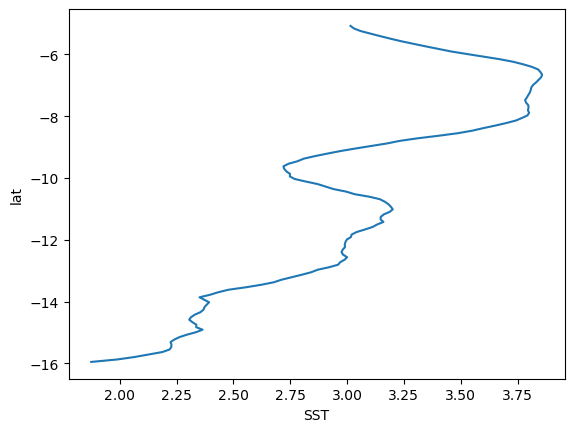

In [11]:
CUI = (SST_off.mean('lon') - SST_in.mean('lon'))
CUI.SST.mean('time').rolling(lat=13).mean().sel(lat=slice(-16,-5)).plot(y='lat')

In [17]:
# CUI = CUI.SST.rename('CUI_cc')
# CUI.to_dataset().to_netcdf('CUI.nc')

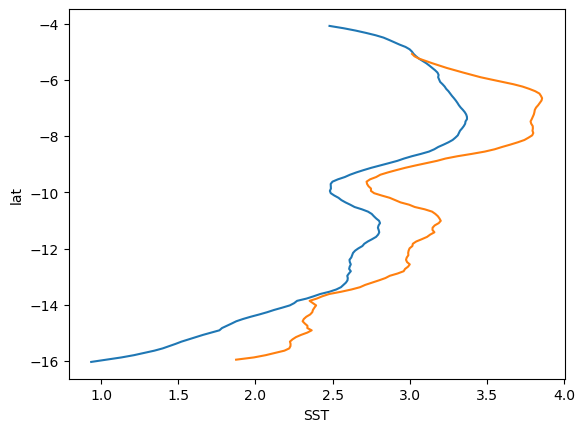

In [15]:
xr.open_dataset('CUI_oldmask.nc').compute().CUI_cc.mean('time').rolling(lat=13).mean().plot(y='lat')
CUI.SST.mean('time').rolling(lat=13).mean().sel(lat=slice(-16,-5)).plot(y='lat')

In [18]:
xr.open_dataset('CUI.nc').compute()

<xarray.Dataset> Size: 554kB
Dimensions:  (time: 432, lat: 159)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    CUI_cc   (time, lat) float64 550kB 0.8344 1.302 1.668 ... 1.036 0.908 0.7906